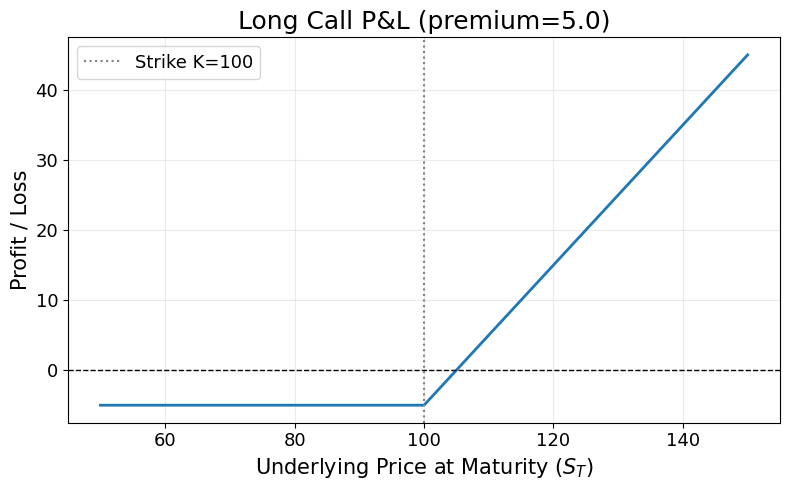

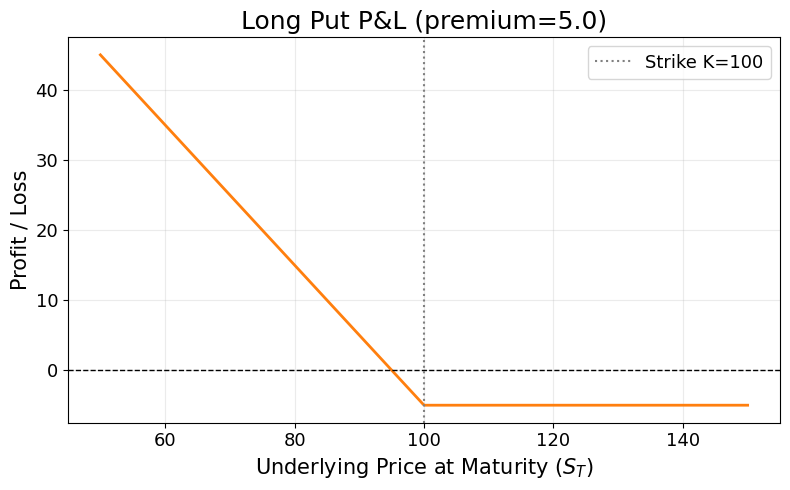

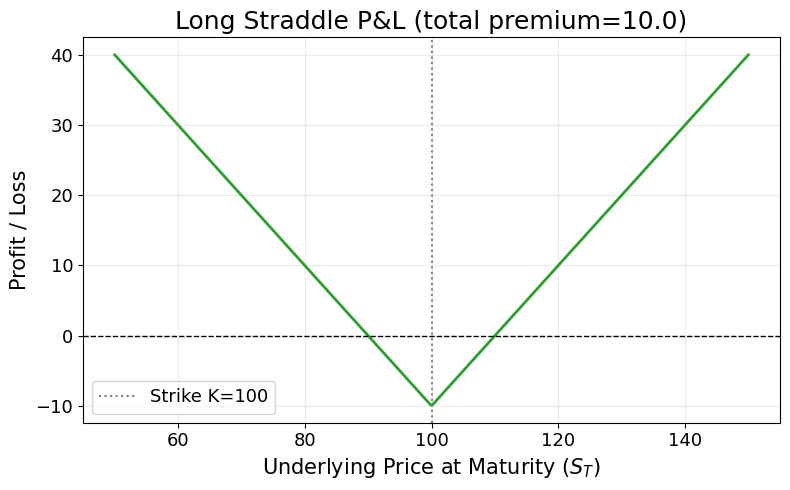

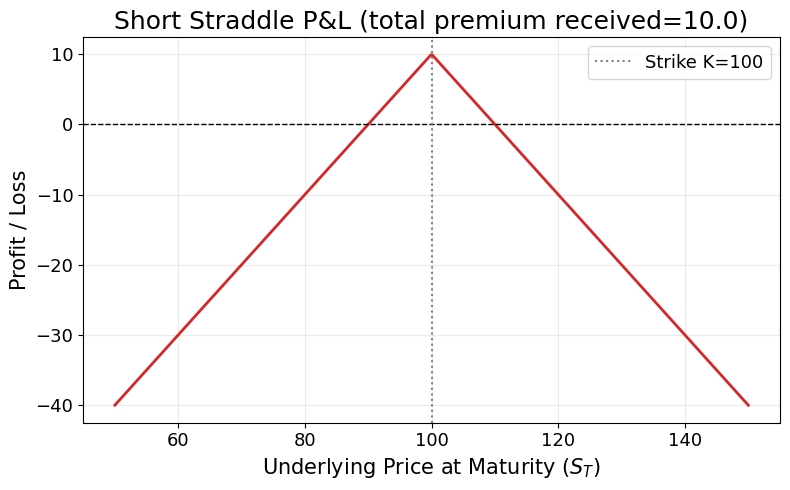

Saved files:
- pnl_call.png
- pnl_put.png
- pnl_long_straddle.png
- pnl_short_straddle.png

Tip: change call_price and put_price to match market quotes.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Parameters
K = 100  # strike price
call_price = 5.0  # premium paid for 1 call
put_price = 5.0   # premium paid for 1 put
s_min, s_max = 50, 150
num_points = 500

# Typography settings for larger text in exported figures
TITLE_FONTSIZE = 18
LABEL_FONTSIZE = 15
TICK_FONTSIZE = 13
LEGEND_FONTSIZE = 13

# Price grid at maturity
S_T = np.linspace(s_min, s_max, num_points)

# Payoff at maturity
call_payoff = np.maximum(S_T - K, 0)
put_payoff = np.maximum(K - S_T, 0)
long_straddle_payoff = call_payoff + put_payoff
short_straddle_payoff = -long_straddle_payoff

# Net P&L (includes option prices)
long_call_pnl = call_payoff - call_price
long_put_pnl = put_payoff - put_price
long_straddle_pnl = long_straddle_payoff - (call_price + put_price)
short_straddle_pnl = -long_straddle_pnl

# Save directory (same folder as notebook)
out_dir = Path.cwd()
out_dir.mkdir(parents=True, exist_ok=True)


def plot_and_save(x, y, title, ylabel, filename, color):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, y, color=color, linewidth=2)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(K, color="gray", linestyle=":", linewidth=1.5, label=f"Strike K={K}")
    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    ax.set_xlabel("Underlying Price at Maturity ($S_T$)", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=LEGEND_FONTSIZE)
    fig.tight_layout()
    fig.savefig(out_dir / filename, dpi=300)
    plt.show()


plot_and_save(
    S_T,
    long_call_pnl,
    f"Long Call P&L (premium={call_price})",
    "Profit / Loss",
    "pnl_call.png",
    "tab:blue",
)
plot_and_save(
    S_T,
    long_put_pnl,
    f"Long Put P&L (premium={put_price})",
    "Profit / Loss",
    "pnl_put.png",
    "tab:orange",
)
plot_and_save(
    S_T,
    long_straddle_pnl,
    f"Long Straddle P&L (total premium={call_price + put_price})",
    "Profit / Loss",
    "pnl_long_straddle.png",
    "tab:green",
)
plot_and_save(
    S_T,
    short_straddle_pnl,
    f"Short Straddle P&L (total premium received={call_price + put_price})",
    "Profit / Loss",
    "pnl_short_straddle.png",
    "tab:red",
)

print("Saved files:")
print("- pnl_call.png")
print("- pnl_put.png")
print("- pnl_long_straddle.png")
print("- pnl_short_straddle.png")
print("\nTip: change call_price and put_price to match market quotes.")